In [1]:
import os
import numpy as np
import pandas as pd
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
os.environ["NUMBA_THREADING_LAYER"] = "workqueue"
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_MAX_ACTIVE_LEVELS"] = "1"
import stark as sk

In [2]:
# ==========================================
# 0. 初始化核心数据对象 HData
# ==========================================
print(">>> 初始化 HData 对象...")
resolutions = [ 50000, 100000,500000, 1000000,]
hdata = sk.HData(
    data_dir="/Users/ckw/warehouse/metacell/data/test_700_snm3c",
    output_dir="/Users/ckw/warehouse/metacell/stark/test_output",
    genome_reference_path="/Users/ckw/warehouse/metacell/hg19.fa.chrom.sizes",
    chrom_list=[f"chr{i}" for i in range(1, 23)],
    resolutions=resolutions
)

>>> 初始化 HData 对象...


In [3]:
# ==========================================
# 1. 执行数据预处理与加载
# ==========================================
print("\n>>> 1. 执行数据预处理与加载...")
sk.pp.process_and_load(
    hdata, 
    force_process=True, 
    cpu_num=10, 
    gpu_num=8
)


>>> 1. 执行数据预处理与加载...
====== calculating depth =======
====== depth calculation completed =======
====== Processing multiple resolutions =======
====== Processing resolution: 50000 =======
Files for resolution 50000 already exist. Skipping processing.
====== Processing resolution: 100000 =======
Files for resolution 100000 already exist. Skipping processing.
====== Processing resolution: 500000 =======
Files for resolution 500000 already exist. Skipping processing.
====== Processing resolution: 1000000 =======
Files for resolution 1000000 already exist. Skipping processing.
✅ 数据底层处理 (stark_process) 完成。
✅ 数据已成功挂载到 HData 对象中。


In [4]:
lb = []
path = '/Users/ckw/warehouse/metacell/data/test_700_snm3c'
for val in os.listdir(path):
    if val.endswith('.pairs'):
        lb.append(val.split('.pairs')[0].split('_')[1])
hdata.obs['label'] = lb


>>> 2. 推荐 MetaCell 数量...
推荐 MetaCell 数量的目标测序深度范围: 10000000.00 - 100000000.00
正在构建 AnnData 并计算近邻图 (n_neighbors=15)...
正在执行 Leiden 聚类 (resolution=2.0)...
✅ 聚类完成，共发现 15 个聚类簇。

💡 基于 Leiden 聚类的推荐结果: 最终总 n_metacells 范围 = [15, 75]


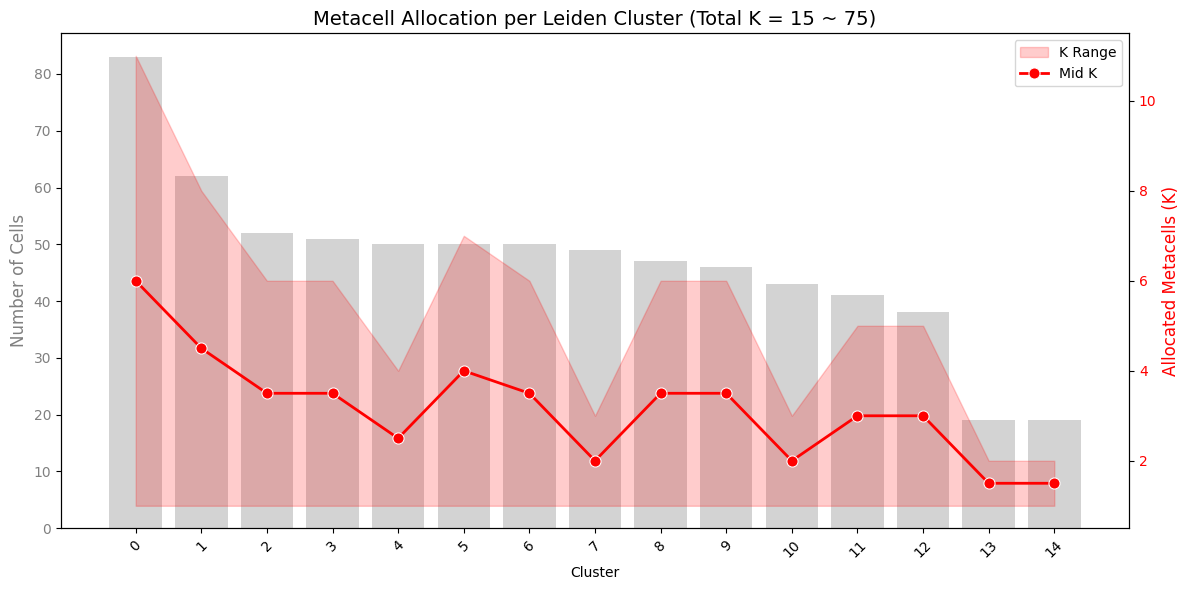

In [5]:
# ==========================================
# 2. 推荐 MetaCell 数量 (带原有参数)
# ==========================================
print("\n>>> 2. 推荐 MetaCell 数量...")
min_depth = 10000000
max_depth = 100000000
print(f"推荐 MetaCell 数量的目标测序深度范围: {min_depth:.2f} - {max_depth:.2f}")
min_k, max_k = sk.tl.recommend_metacell_num(
    hdata,
    target_depth_min=min_depth,  # 下限 20M
    target_depth_max=max_depth ,  # 上限 40M
    resolution_param=2.0,     # Leiden resolution
    n_neighbors=15,
    ref_view=1000000
)

In [6]:
result = {}
for num in range(15,75):
    # ==========================================
    # 3. 初始化模型参数 (还原所有原有超参数)
    # ==========================================
    print("\n>>> 3. 初始化模型参数...")
    sk.tl.init_model(
    hdata, 
    n_metacells=num,            # 目标 MetaCell 数量
    lambda_sparse=0.0000,      # 稀疏惩罚
    lambda_balance=0.01,       # 平衡惩罚
    lambda_consistency=0.001,  # 一致性惩罚
    max_iter=100,              # 最大迭代次数
    # --- scHi-C 深度优化参数 ---
    min_size_threshold=0.002,  # 重生阈值
    respawn_interval=10,       # 检查频率
    split_metric='pca'         # 分裂准则
    )


    # ==========================================
    # 4. 计算核矩阵
    # ==========================================
    print("\n>>> 4. 计算核矩阵...")
    sk.tl.compute_kernels(hdata)
    # ==========================================
    # 5. 初始化 Waypoint (还原原有初始化参数)
    # ==========================================
    print("\n>>> 5. 初始化 Waypoints (K-Means++)...")
    sk.tl.initialize_waypoints(
    hdata, 
    seed=32, 
    n_micro_clusters=100,       # 对应原代码中的 30
    ref_view_res=500000
    )



    # ==========================================
    # 6. 核心拟合优化
    # ==========================================
    print("\n>>> 6. 开始模型拟合优化...")
    sk.tl.fit(hdata, n_threads=10)
    # 执行评估
    purity_df, metrics = sk.tl.evaluate(hdata)

    # 最终对比图
    sk.pl.plot_umap_comparison(hdata, ref_view_res=500000)

    print("\n🎉 全流程运行完毕！")
    result[num] = metrics
# save result
np.save('result.npy', result)




>>> 3. 初始化模型参数...
✅ 模型参数初始化完成，目标 MetaCell 数量: 15

>>> 4. 计算核矩阵...
步骤1: 构建核矩阵 (Cache Dir: None)
  [View 0] 开始内部计算 RBF 核矩阵 (Input: (700, 84))...


/Users/ckw/warehouse/metacell/stark/stark/utils/model.py:99: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  tmp = ad.AnnData(view)


KeyboardInterrupt: 

In [31]:
res = np.load('/Users/ckw/warehouse/metacell/stark/result.npy',allow_pickle=True)
df = pd.DataFrame(res.item()).T
# plot 
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(df.index, df['accuracy'], marker='o', label='accuracy')
plt.plot(df.index, df['global_score'], marker='o', label='global_score')
plt.plot(df.index, df['mean_purity'], marker='o', label='mean_purity')
plt.xlabel('Number of MetaCells')
plt.ylabel('Score')

plt.legend()
plt.grid()
plt.show()

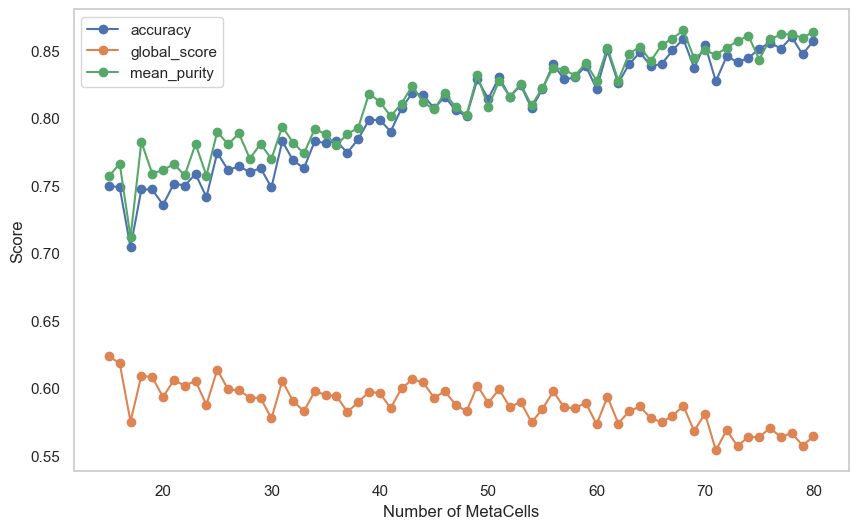

In [ ]:
# 执行评估
purity_df, metrics = sk.tl.evaluate(hdata)

# 最终对比图
sk.pl.plot_umap_comparison(hdata, ref_view_res=500000)

print("\n🎉 全流程运行完毕！")zz

In [ ]:
sk.pl.plot_basic_purity(hdata,)

In [ ]:
sk.pl.plot_metacell_sizes(hdata,)

In [ ]:
sk.pl.plot_ep_score(hdata)

In [ ]:
sk.pl.plot_specific_metacell(hdata, idx=0, ref_view_res=500000)

In [ ]:
sk.tl.aggregate_metacell_pairs(hdata,  n_jobs=2, force_aggregate=False, 
                             convert_to_cool=True, convert_to_mcool=True,
                             resolution=10000, mcool_resolutions=[ 50000, 100000,500000, 1000000,2000000], verbose=True)
# ,2000000

In [ ]:
sk.pl.plot_metacells(hdata)

In [ ]:
chrom = 'chr2'
start = 169600000
end = 173600000
resolution = 50000

In [ ]:

sk.pl.plot_metacell_heatmap(hdata=hdata, 
                            metacell_id=26,
                            chrom=chrom,
                            balance=False,
                            resolution=50000,
                            start=start,
                            log1p=True,
                            end=end)

In [ ]:
hdata.metacells

In [ ]:
hdata

In [ ]:
sk.pl.plot_celltype_heatmaps(hdata=hdata,
                             chrom=chrom,
                             cell_type='ODC',
                            balance=False,
                            resolution=50000,
                            start=start,
                            cell_type_col='dominant_label',
                            ncols=3,
                            end=end)

In [ ]:
sk.pl.plot_celltype_heatmaps(hdata=hdata,
                             chrom=chrom,
                             cell_type='L5',
                            balance=False,
                            resolution=50000,
                            start=start,
                            cell_type_col='dominant_label',
                            ncols=3,
                            vmax=2.5,
                            log1p=True,
                            fill_diagonal_zero=True,
                            end=end)